# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [2]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% Load data from simulation of system dynamic model. 
% Data file contains the variables: model dT t u x z
load readonly/simOut.mat

rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

### Helper functions for the sigma-point Kalman filter
The next notebook cells implement the initialization and iteration functions for the SPKF.

In [3]:
% SPKF initialization function, called once at the beginning of the simulation
function spkfData = initSPKF(xhat0,SigmaX0,priorU,dT,model)
  spkfData.xhat   = xhat0;        % Initial state description  
  spkfData.SigmaX = SigmaX0;      % Initial estimation-error covariance 
  spkfData.SigmaV = model.SigmaV; % Sensor-noise covariance 
  spkfData.SigmaW = model.SigmaW; % Process-noise covariance
  spkfData.Sw     = model.Sw;     % Cts-time process-noise covariance
  spkfData.priorU = priorU;       % Previous value of input force
  spkfData.model  = model; % Store model data structure too
  spkfData.Qbump  = 5;     % In case SigmaX collapses

  spkfData.Snoise = real(chol(diag([spkfData.Sw/dT; spkfData.SigmaV]),'lower'));
  % Alternate implementation for matrix SigmaW
  % spkfData.Snoise = real(chol(blkdiag(spkfData.SigmaW,spkfData.SigmaV),'lower'));
  
  % SPKF specific parameters
  nx = length(spkfData.xhat); spkfData.nx = nx; % state-vector length
  nz = 1; spkfData.nz = nz; % measurement-vector length
  nu = 1; spkfData.nu = nu; % input-vector length
  nw = size(model.Sw,1); spkfData.nw = nw; % process-noise-vector length
  % Alternate implementation for matrix SigmaW
  % nw = size(model.SigmaW,1); spkfData.nw = nw; % process-noise-vector length
  nv = size(model.SigmaV,1); spkfData.nv = nv; % sensor-noise-vector length
  na = nx+nw+nv; spkfData.na = na;     % augmented-state-vector length
  
  h = sqrt(3); spkfData.h = h; % SPKF/CDKF tuning factor  
  Weight1 = (h*h-na)/(h*h); % weighting factors when computing mean
  Weight2 = 1/(2*h*h);      % and covariance
  spkfData.Wm = [Weight1; Weight2*ones(2*na,1)]; % mean
  spkfData.Wc = spkfData.Wm;                     % covar

  % previous value of input
  spkfData.priorU = priorU;
  
  % store model data structure too
  spkfData.model = model;
end

In [4]:
% SPKF iteration function, called once every measurement interval
function [xhat,bounds,spkfData] = iterSPKF(uk,zk,dT,spkfData)
  model = spkfData.model;
  SQRT = @(x) sqrt(max(0,x)); % "Safe" square root

  % Get data stored in spkfData structure
  priorU = spkfData.priorU;
  SigmaX = spkfData.SigmaX;
  xhat = spkfData.xhat;
  nx = spkfData.nx;
  nw = spkfData.nw;
  nv = spkfData.nv;
  na = spkfData.na;
  Snoise = spkfData.Snoise;
  Wc = spkfData.Wc;
  
  % Step 1a: State estimate time update
  %          - Create xhatminus augmented SigmaX points
  %          - Extract xhatminus state SigmaX points
  %          - Compute weighted average xhatminus(k)

  % Step 1a-1: Create augmented SigmaX and xhat
  [sigmaXa,p] = chol(SigmaX,'lower'); 
  if p>0
    fprintf('Cholesky error.  Recovering...\n');
    theAbsDiag = abs(diag(SigmaX));
    sigmaXa = diag(max(SQRT(theAbsDiag),SQRT(spkfData.Sw/dT)));
    % Alternate implementation for matrix SigmaW
    % sigmaXa = diag(max(SQRT(theAbsDiag),SQRT(spkfData.SigmaW)));
  end
  sigmaXa=[real(sigmaXa) zeros([nx nw+nv]); zeros([nw+nv nx]) Snoise];
  xhata = [xhat; zeros([nw+nv 1])];
  % NOTE: sigmaXa is lower-triangular

  % Step 1a-2: Calculate SigmaX points (strange indexing of xhata to 
  % avoid "repmat" call, which is very inefficient in MATLAB)
  Xa = xhata(:,ones([1 2*na+1])) + ...
       spkfData.h*[zeros([na 1]), sigmaXa, -sigmaXa];

  % Step 1a-3: Time update from last iteration until now
  %     stateEqn(xold,current,xnoise)
  Xx = stateEqn(Xa(1:nx,:),priorU,dT,Xa(nx+1:nx+nw,:)); 
  xhat = Xx*spkfData.Wm;

  % Step 1b: Error covariance time update
  %          - Compute weighted covariance sigmaminus(k)
  %            (strange indexing of xhat to avoid "repmat" call)
  Xs = Xx - xhat(:,ones([1 2*na+1]));
  SigmaX = Xs*diag(Wc)*Xs';
  
  % Step 1c: Output estimate
  %          - Compute weighted output estimate yhat(k)
  Z = outputEqn(Xx,Xa(nx+nw+1:end,:),model);
  zhat = Z*spkfData.Wm;

  % Step 2a: Estimator gain matrix
  Zs = Z - zhat(:,ones([1 2*na+1]));
  SigmaXZ = Xs*diag(Wc)*Zs';
  SigmaZ  = Zs*diag(Wc)*Zs';
  L = SigmaXZ/SigmaZ; 

  % Step 2b: State estimate measurement update
  r = zk - zhat; % residual.  Use to check for sensor errors...
  if r^2 > 100*SigmaZ, L(:)=0.0; end 
  xhat = xhat + L*r;

  % Step 2c: Error covariance measurement update
  SigmaX = SigmaX - L*SigmaZ*L';

  % Q-bump code
  if r^2 > 16*SigmaZ % bad output estimate by 4 std. devs, bump Q 
    fprintf('Bumping SigmaX\n');
    SigmaX = SigmaX*spkfData.Qbump;
  end
  [~,S,V] = svd(SigmaX); % Implement Higham method to help robustness
  HH = V*S*V';
  SigmaX = (SigmaX + SigmaX' + HH + HH')/4; 
  
  % Save data in ekfData structure for next time...
  spkfData.priorU = uk;
  spkfData.SigmaX = SigmaX;
  spkfData.xhat = xhat;
  bounds = 3*sqrt(diag(SigmaX));
  
  % Calculate new states for all of the old state vectors in xold.  
  function xnew = stateEqn(xold,priorU,dT,xnoise)
    % Compute linear homogeneous part
    xnew = [1 dT; -model.k1*dT/model.m 1-model.b*dT/model.m]*xold;
    % Add on nonlinear and forcing part
    xnew(2,:) = xnew(2,:) - model.k2*dT*xold(1,:).^3/model.m + ...
                  dT/model.m*(priorU + xnoise);
    % Alternate implementation for matrix SigmaW                  
    % xnew(2,:) = xnew(2,:) - model.k2*dT*xold(1,:).^3/model.m + ...
    %             dT/model.m*priorU;
    % xnew = xnew + xnoise;
  end

  % Calculate cell output voltage for all of state vectors in xhat
  function zhat = outputEqn(xhat,znoise,model)
    zhat = atan(xhat(1,:)/model.d) + znoise;
  end
end

### Implementing the sigma-point Kalman filter
The next notebook cells implement the main code of the sigma-point Kalman filter.

In [5]:
% Determine number of states and timesteps
[nx,nt] = size(x); 

In [6]:
% Reserve storage for results
xhatstore  = zeros(nx,nt);
boundstore = zeros(nx,nt);

% Covariance values
SigmaX0 = 0.1*eye(nx,nx); % uncertainty of initial state
xhat0   = zeros(nx,1);

% Create spkfData structure and initialize variables 
spkfData = initSPKF(xhat0,SigmaX0,u(1),dT,model);

% Now, enter loop for remainder of time, where we update the EKF
% once per sample interval
for k = 2:length(t)
  uk = u(k); % "measure" input force
  zk = z(k); % "measure" nonlinear output
  
  % Compute estimate of present state vector and its bounds
  [xhatstore(:,k),boundstore(:,k),spkfData] = iterSPKF(uk,zk,dT,spkfData);
end

### Plot simulation outputs from the sigma-point Kalman filter
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

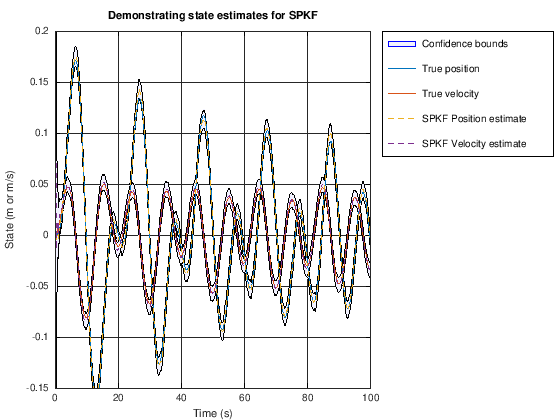

In [7]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatstore-boundstore fliplr(xhatstore+boundstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 

h2 = plot(t,x',t,xhatstore','--'); ylim([-0.15 0.2]);
legend([h2;h1a],{'True position','True velocity','SPKF Position estimate',...
  'SPKF Velocity estimate','Confidence bounds'},'Location','BestOutside'); 
title('Demonstrating state estimates for SPKF'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

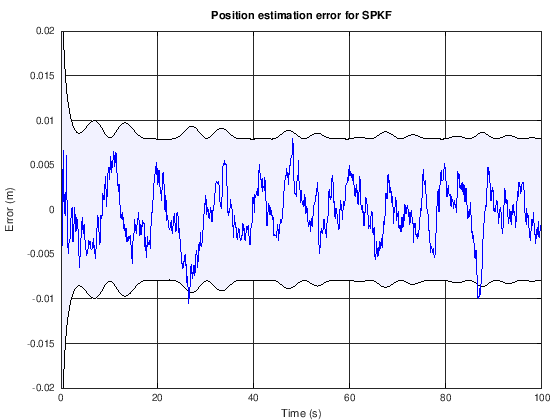

In [8]:
spkfErr = x - xhatstore;
fill([t fliplr(t)],[-boundstore(1,:) fliplr(boundstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,spkfErr(1,:),'b'); ylim([-0.02 0.02])
title('Position estimation error for SPKF'); 
xlabel('Time (s)'); ylabel('Error (m)'); 

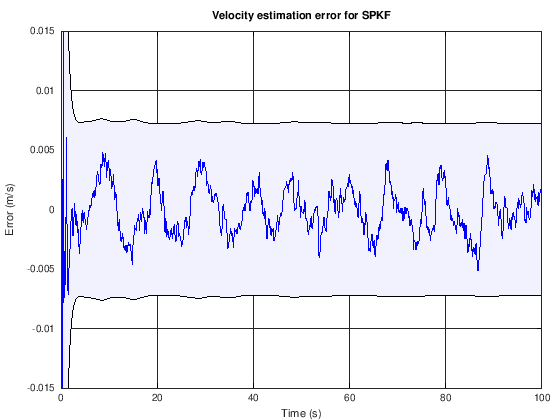

In [9]:
fill([t fliplr(t)],[-boundstore(2,:) fliplr(boundstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,spkfErr(2,:),'b'); ylim([-0.015 0.015]);
title('Velocity estimation error for SPKF'); 
xlabel('Time (s)'); ylabel('Error (m/s)'); 

In [10]:
% Compute and output some statistics
fprintf('RMS state estimation error = %g\n',rms(spkfErr(:)));
ind = find(abs(spkfErr(:))>boundstore(:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(boundstore(:))*100);

RMS state estimation error = 0.00328206
Time error outside bounds = 0.44955%
